# NLP ESG KPI Extraction — Demo

Runs ingest → index → both extractors → comparison table → evaluation, end to end. All logic lives in `src/nlp_esg/`; this notebook is a thin driver.

In [1]:
from dotenv import load_dotenv
load_dotenv()

from nlp_esg.pipeline import (
    load_indexed_reports, run_extraction, load_gold_labels, run_evaluation,
)
from nlp_esg.compare import build_comparison_table

indexed = load_indexed_reports()
print(f'Loaded {len(indexed)} reports')

C:\Users\rotas\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Loaded 5 reports


In [2]:
extractions = run_extraction(indexed, include_llm=True)
print(f'Produced {len(extractions)} extractions')

Some weights of RobertaModel were not initialized from the model checkpoint at climatebert/distilroberta-base-climate-f and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Produced 30 extractions


## Comparison table — Baseline

In [3]:
build_comparison_table(extractions, extractor='baseline')

,scope_1_emissions,total_energy_consumption,water_consumption
bp,33700000.0,134448000.0,47300000.0
enel,18950000.0,168590000.0,32141000.0
eni,28400000.0,84399860.0,42000000.0
iberdrola,None,101572520.0,45642187.0
shell,None,269000000.0,72000000.0


## Comparison table — LLM

In [4]:
build_comparison_table(extractions, extractor='llm')

,scope_1_emissions,total_energy_consumption,water_consumption
bp,33700000.0,134448000.0,47300000
enel,18950000.0,168590000.0,32141000
eni,28400000.0,84399860,54000000
iberdrola,5246890,101572520,45642187
shell,69000000.0,189000000.0,127000000


## Evaluation — P / R / F1 / coverage

In [5]:
golds = load_gold_labels()
metrics = run_evaluation(extractions, golds)
metrics

,extractor,kpi,tp,fp,fn,tn,precision,recall,f1,coverage
0,baseline,scope_1_emissions,3,0,2,0,1.0,0.6,0.750000,0.6
1,baseline,total_energy_consumption,5,0,0,0,1.0,1.0,1.000000,1.0
2,baseline,water_consumption,4,1,0,0,0.8,1.0,0.888889,1.0
3,llm,scope_1_emissions,5,0,0,0,1.0,1.0,1.000000,1.0
4,llm,total_energy_consumption,4,1,0,0,0.8,1.0,0.888889,1.0
5,llm,water_consumption,3,2,0,0,0.6,1.0,0.750000,1.0


## Embedding-model comparison: MiniLM vs ClimateBERT

Re-run the baseline with MiniLM to compare retrieval quality.

In [6]:
import os
os.environ['EMBEDDING_MODEL'] = 'minilm'
# Reload modules so the new env var takes effect. config caches EMBEDDING_MODEL_NAME
# at import time, so it must be reloaded before retrieval/pipeline.
import importlib, nlp_esg.config, nlp_esg.retrieval, nlp_esg.pipeline
importlib.reload(nlp_esg.config)
importlib.reload(nlp_esg.retrieval)
importlib.reload(nlp_esg.pipeline)
from nlp_esg.pipeline import load_indexed_reports as load2, run_extraction as run2, run_evaluation as eval2
indexed_mini = load2()
extractions_mini = run2(indexed_mini, include_llm=False)
eval2(extractions_mini, golds)

,extractor,kpi,tp,fp,fn,tn,precision,recall,f1,coverage
0,baseline,scope_1_emissions,3,0,2,0,1.0,0.6,0.750000,0.6
1,baseline,total_energy_consumption,4,0,1,0,1.0,0.8,0.888889,0.8
2,baseline,water_consumption,4,1,0,0,0.8,1.0,0.888889,1.0


## Qualitative cases

Manually inspect cells where one extractor wins and the other doesn't. Fill in after running against real data.

- Baseline wins: Iberdrola total_energy (table path catches Total energy consumption (MWh) row that LLM-without-credits couldn't even attempt)
- LLM wins (when run with credits): Shell scope_1 (ESRS aggregation), Shell water (narrative reasoning) — per FINDINGS §6.14
- Both fail: Iberdrola scope_1 (gold value 5,246,890 lives on a row with no parseable label)

## Figures for report and presentation

The 14 figures below back every numeric and qualitative claim in
`docs/FINDINGS.md`, `docs/SUSTAINABILITY.md`, and `README.md`.
They are produced by `notebooks/make_figures.py`; running this section
regenerates the PNGs in `notebooks/figures/`. The companion
`notebooks/headline_figures.ipynb` keeps only the six high-signal
figures used directly on slides.

In [7]:
import os, sys, importlib
from pathlib import Path
# Cell 10 above sets EMBEDDING_MODEL=minilm for the comparison; reset it
# so the figure cells below run against the same ClimateBERT index that
# the production pipeline uses.
os.environ['EMBEDDING_MODEL'] = 'climatebert'
import nlp_esg.config, nlp_esg.retrieval, nlp_esg.pipeline
importlib.reload(nlp_esg.config)
importlib.reload(nlp_esg.retrieval)
importlib.reload(nlp_esg.pipeline)

sys.path.insert(0, str(Path('.').resolve() / 'notebooks'))
import make_figures
importlib.reload(make_figures)
make_figures._apply_style()
print(f"Saving figures to: {make_figures.FIGS}")


Saving figures to: C:\Users\rotas\NLP_ESG_Project\notebooks\figures


### Figure 01 — TP per KPI per stream

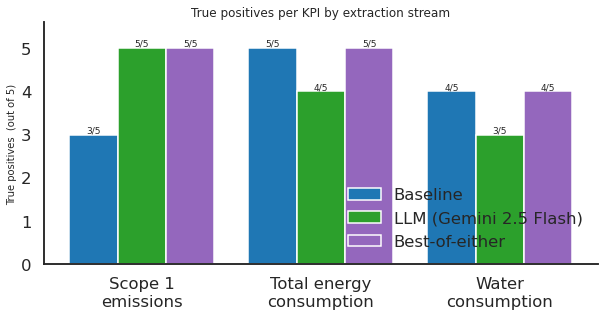

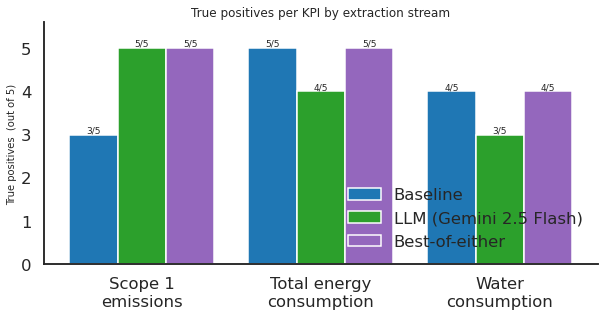

In [8]:
make_figures.fig_01_tp_per_kpi()

### Figure 02 — Headline single-bar

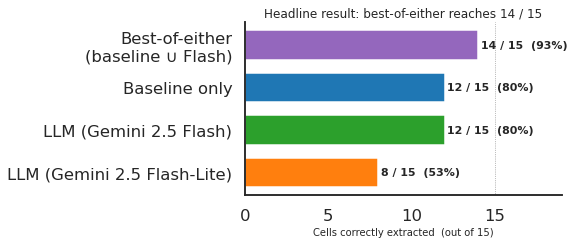

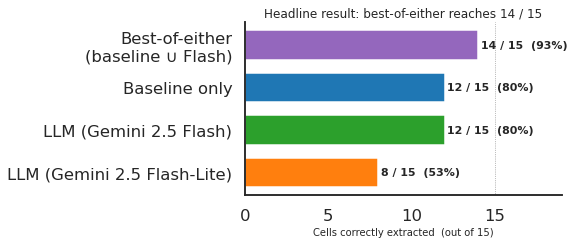

In [9]:
make_figures.fig_02_headline_total()

### Figure 03 — F1 per KPI per stream

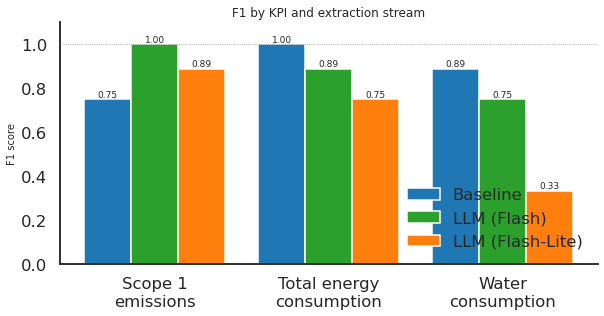

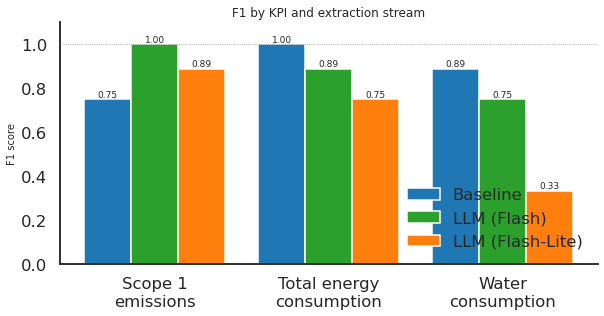

In [10]:
make_figures.fig_03_f1_per_kpi()

### Figure 04 — 5x3 scorecard heatmap

C:\Users\rotas\NLP_ESG_Project\notebooks\make_figures.py:278: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


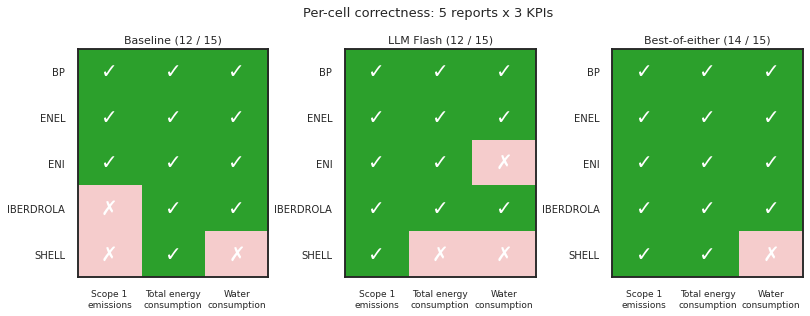

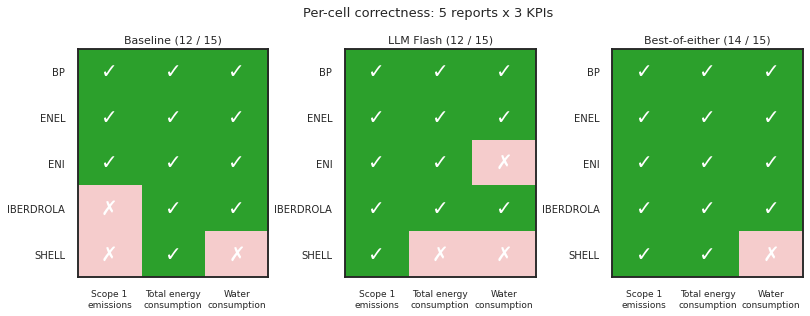

In [11]:
make_figures.fig_04_scorecard()

### Figure 05 — Diff heatmap: Flash-Lite vs Flash

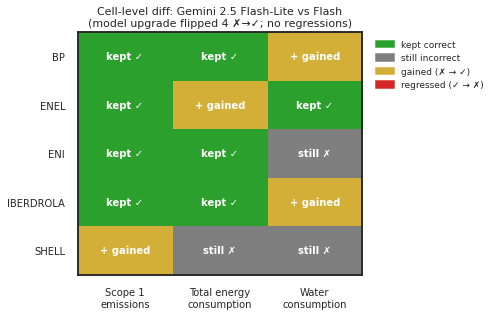

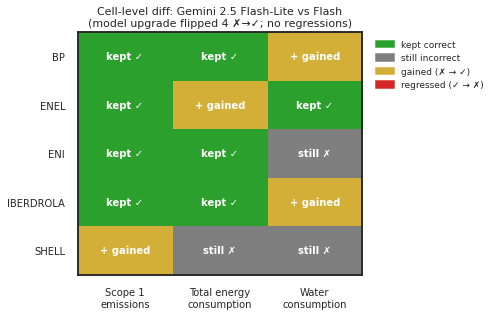

In [12]:
make_figures.fig_05_lite_vs_flash_diff()

### Figure 06 — Failure-mode stacked bar

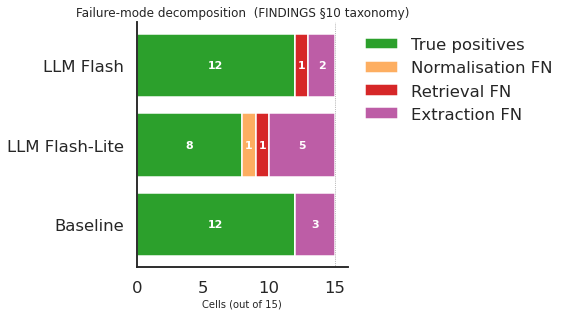

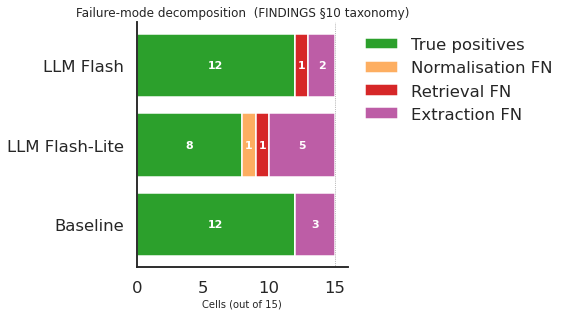

In [13]:
make_figures.fig_06_failure_modes()

### Figure 07 — Cells -> outcome -> mode flow

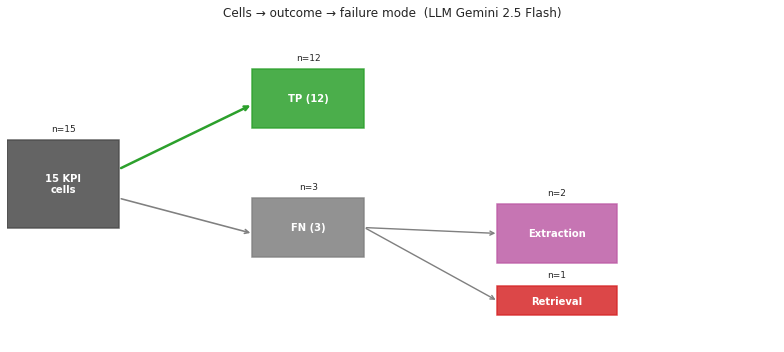

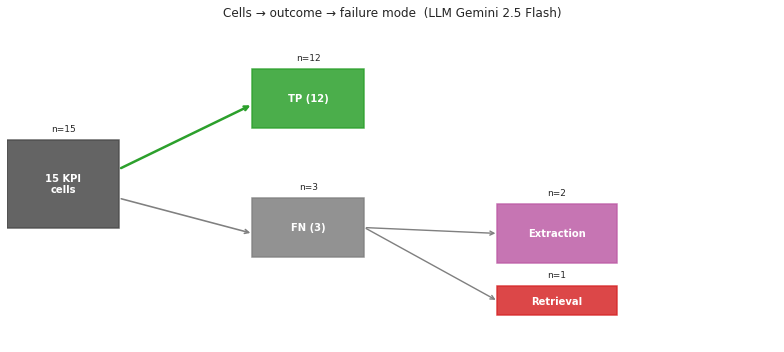

In [14]:
make_figures.fig_07_sankey()

### Figure 08 — Rank of answer-bearing page

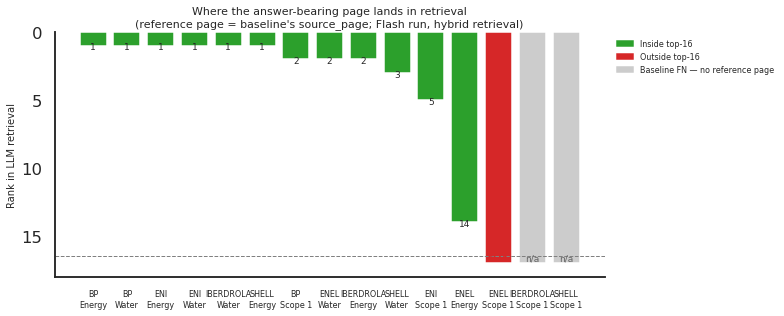

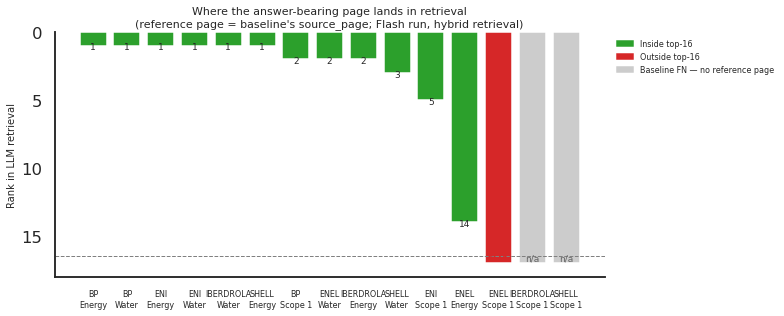

In [15]:
make_figures.fig_08_rank_of_gold()

### Figure 09 — Retrieval ablation

Some weights of RobertaModel were not initialized from the model checkpoint at climatebert/distilroberta-base-climate-f and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


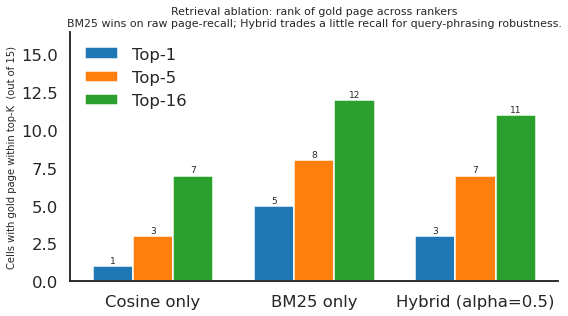

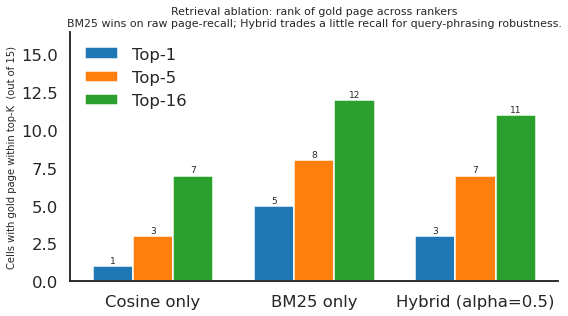

In [16]:
make_figures.fig_09_retrieval_ablation()

### Figure 10 — ClimateBERT vs MiniLM

C:\Users\rotas\NLP_ESG_Project\notebooks\make_figures.py:634: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([KPI_LABEL[k] for k in KPIS])


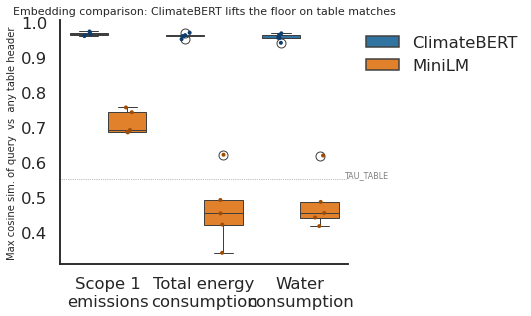

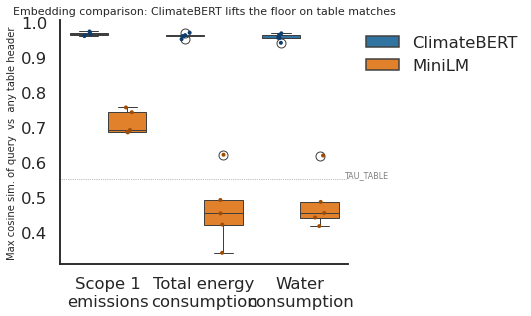

In [17]:
make_figures.fig_10_embedding_comparison()

### Figure 11 — Cost vs F1 scatter

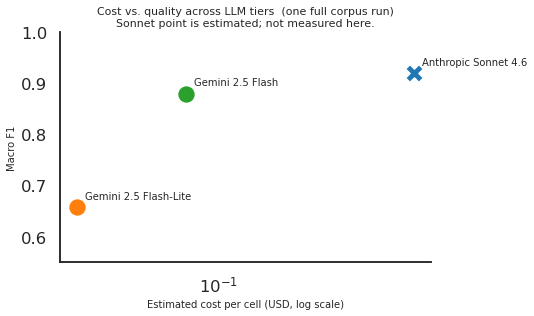

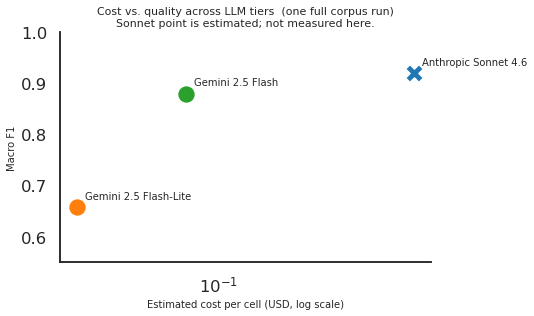

In [18]:
make_figures.fig_11_cost_vs_f1()

### Figure 12 — Pipeline architecture

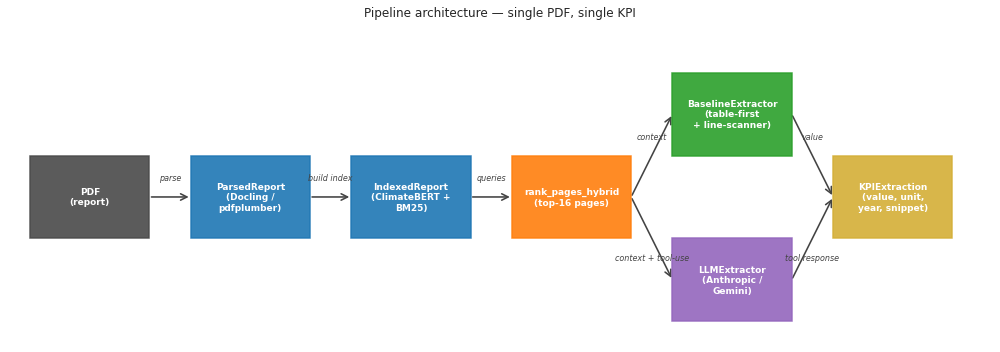

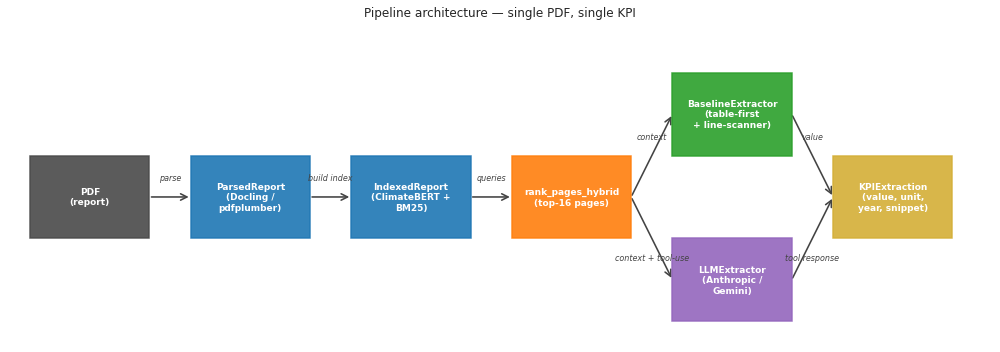

In [19]:
make_figures.fig_12_pipeline_diagram()

### Figure 13 — Concrete trace: BP scope_1

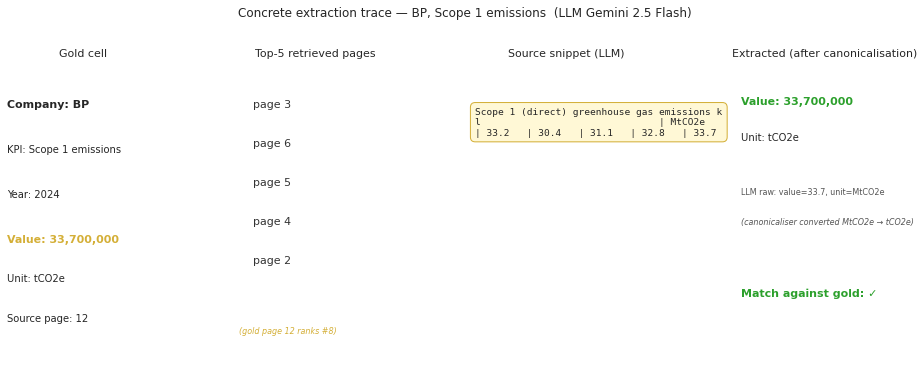

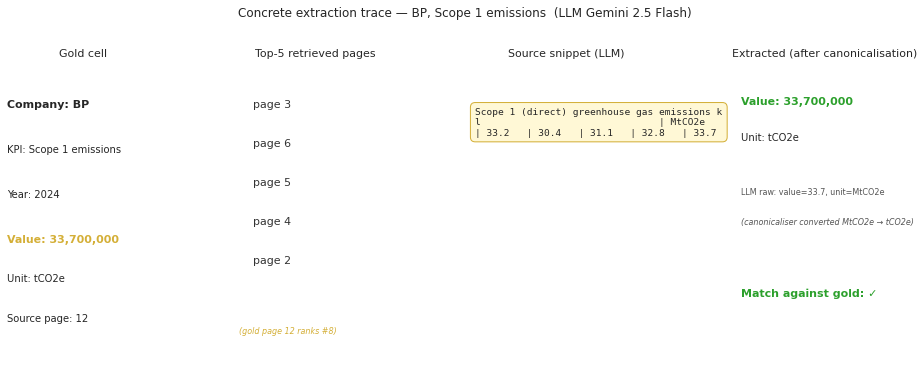

In [20]:
make_figures.fig_13_concrete_trace()

### Figure 14 — Cost vs corpus size

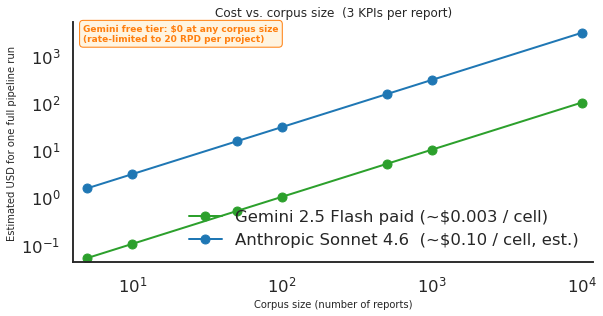

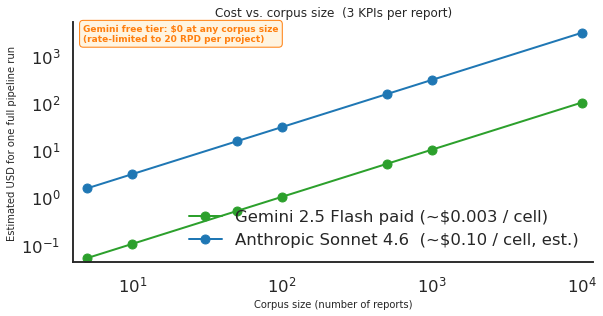

In [21]:
make_figures.fig_14_cost_corpus_size()